In [100]:
# Imports pour exploration et chargement des données
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [101]:
# Jeu FraudShield : même fichier que dans `data/` à la racine du dépôt (ou Colab).
_repo = Path.cwd()
_candidates = [
    _repo / "data" / "FraudShield_Banking_Data.csv",
    _repo.parent / "data" / "FraudShield_Banking_Data.csv",
    _repo / "docs" / "FraudShield_Banking_Data.csv",
    _repo.parent / "docs" / "FraudShield_Banking_Data.csv",
    Path("/content/FraudShield_Banking_Data.csv"),
]
_csv = next((p for p in _candidates if p.is_file()), None)
if _csv is None:
    raise FileNotFoundError(
        "FraudShield_Banking_Data.csv introuvable. Placez-le dans data/ à la racine du dépôt."
    )

df = pd.read_csv(_csv)
print(f"Chargé : {_csv.resolve()} — {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head()


Chargé : /home/perfect/Documents/GitHub/bank-fraud-detection/data/FraudShield_Banking_Data.csv — 50,000 lignes × 25 colonnes


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


## Exploratory Data Analysis (EDA)

Aperçu de la forme du jeu, qualité des données, variable cible `Fraud_Label`, distributions, corrélations et liens métier (montant, catégories, temps, antécédents).


In [102]:
# --- Forme, types, mémoire ---
print("Dimensions :", df.shape)
print("\n--- Types ---")
display(df.dtypes.to_frame("dtype"))
df.info(memory_usage="deep")

# --- Valeurs manquantes ---
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
print("\nColonnes avec au moins un NaN :")
display(na.to_frame("manquantes") if len(na) else "Aucune valeur manquante.")

# --- Statistiques numériques ---
display(df.describe().T)


Dimensions : (50000, 25)

--- Types ---


,dtype
Transaction_ID,float64
Customer_ID,float64
Transaction_Amount (in Million),float64
Transaction_Time,object
Transaction_Date,object
Transaction_Type,object
Merchant_ID,float64
Merchant_Category,object
Transaction_Location,object
Customer_Home_Location,object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       49991 non-null  object 
 4   Transaction_Date                       49997 non-null  object 
 5   Transaction_Type                       49996 non-null  object 
 6   Merchant_ID                            49993 non-null  float64
 7   Merchant_Category                      49991 non-null  object 
 8   Transaction_Location                   49994 non-null  object 
 9   Customer_Home_Location                 49996 non-null  object 
 10  Distance_From_Home                     49998 non-null  float64
 11  De

,manquantes
Failed_Transaction_Count,11
Customer_ID,10
Transaction_Amount (in Million),9
Transaction_Time,9
Merchant_Category,9
Device_ID,9
Avg_Transaction_Amount (in Million),9
Account_Balance (in Million),9
Daily_Transaction_Count,9
Merchant_ID,7


,count,mean,std,min,25%,50%,75%,max
Transaction_ID,49997.0,550400.968898,259677.602349,100043.0,324445.00,552115.0,775942.0,999992.0
Customer_ID,49990.0,54869.720744,26052.824933,10005.0,32259.25,54720.5,77542.0,99996.0
Transaction_Amount (in Million),49991.0,4.999880,2.582025,1.0,3.00,5.0,7.0,9.0
Merchant_ID,49993.0,54951.375913,25983.342481,10001.0,32545.00,54935.0,77341.0,99996.0
Distance_From_Home,49998.0,300.098564,172.848263,1.0,150.00,301.0,449.0,599.0
Device_ID,49991.0,552563.600088,260186.451027,100053.0,327643.50,553372.0,779903.5,999989.0
Account_Balance (in Million),49991.0,20.993179,10.685467,3.0,12.00,21.0,30.0,39.0
Daily_Transaction_Count,49991.0,3.999460,2.002833,1.0,2.00,4.0,6.0,7.0
Weekly_Transaction_Count,49995.0,12.520032,6.910709,1.0,7.00,13.0,18.0,24.0
Avg_Transaction_Amount (in Million),49991.0,2.989098,1.413400,1.0,2.00,3.0,4.0,5.0


In [103]:
# --- Cible Fraud_Label (Normal / Fraud) ---
fl = df["Fraud_Label"].dropna().astype(str).str.strip()
vc = fl.value_counts()
vc_pct = (fl.value_counts(normalize=True) * 100).round(2)
display(pd.DataFrame({"effectif": vc, "%": vc_pct}))
if len(vc) >= 2:
    print(f"Ratio classe minoritaire / majoritaire : {vc.min() / vc.max():.4f}")

# --- Cardinalités (nombre de valeurs distinctes) ---
card = pd.Series({c: df[c].nunique(dropna=False) for c in df.columns}, name="n_unique").sort_values(
    ascending=False
)
display(card.to_frame())


,effectif,%
Fraud_Label,,
Normal,47573,95.15
Fraud,2423,4.85


Ratio classe minoritaire / majoritaire : 0.0509


,n_unique
IP_Address,49995
Transaction_ID,48639
Device_ID,48633
Customer_ID,38354
Merchant_ID,38315
Transaction_Time,1441
Distance_From_Home,600
Transaction_Date,122
Account_Balance (in Million),38
Weekly_Transaction_Count,25


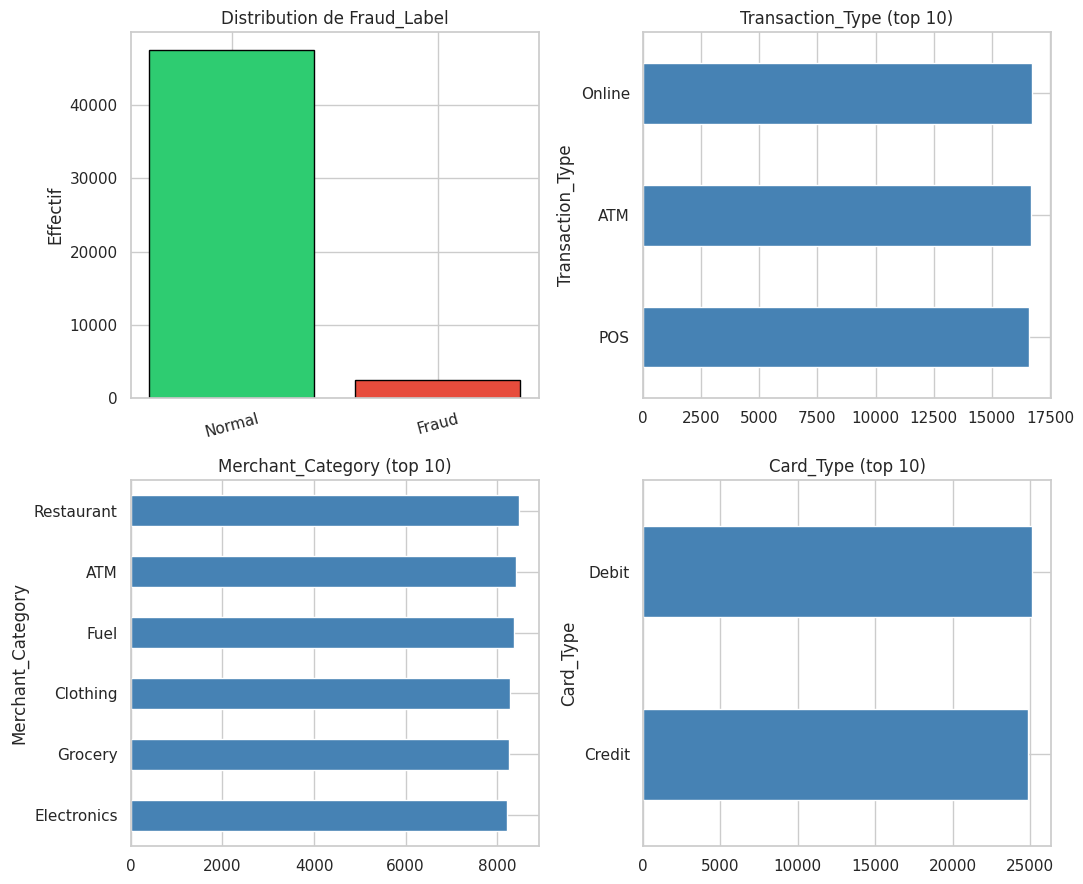

In [104]:
# Graphiques : cible + fréquences des principales modalités catégorielles
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
colors = ["#2ecc71", "#e74c3c", "#95a5a6", "#3498db"]
axes[0, 0].bar(vc.index.astype(str), vc.values, color=colors[: len(vc)], edgecolor="black")
axes[0, 0].set_title("Distribution de Fraud_Label")
axes[0, 0].set_ylabel("Effectif")
axes[0, 0].tick_params(axis="x", rotation=15)

for i, col in enumerate(["Transaction_Type", "Merchant_Category", "Card_Type"]):
    ax = axes.flat[i + 1]
    df[col].value_counts().head(10).sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"{col} (top 10)")

plt.tight_layout()
plt.show()


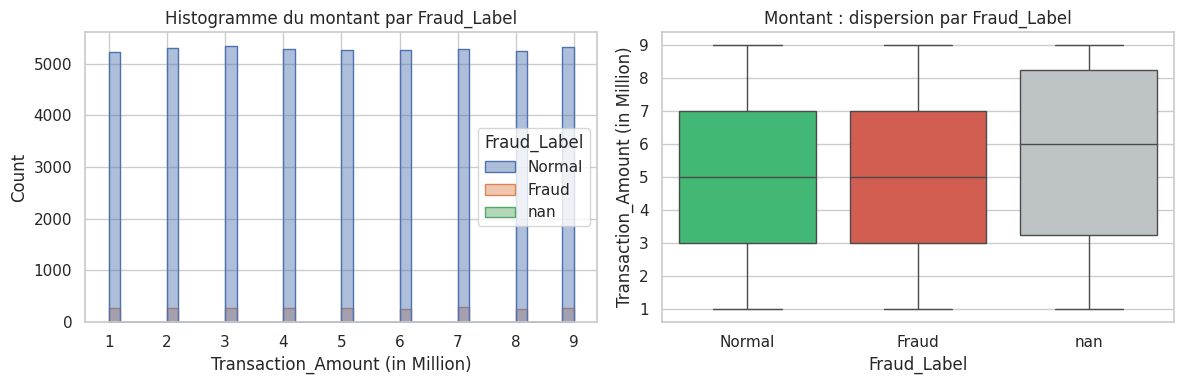

In [105]:
# Montant de transaction : normal vs fraude
amt_col = "Transaction_Amount (in Million)"
fl_str = df["Fraud_Label"].astype(str).str.strip()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(
    df,
    x=amt_col,
    hue=fl_str,
    bins=40,
    ax=axes[0],
    multiple="layer",
    alpha=0.45,
    element="step",
)
axes[0].set_title("Histogramme du montant par Fraud_Label")
sns.boxplot(data=df, x=fl_str, y=amt_col, ax=axes[1], palette=["#2ecc71", "#e74c3c", "#bdc3c7"])
axes[1].set_title("Montant : dispersion par Fraud_Label")
plt.tight_layout()
plt.show()


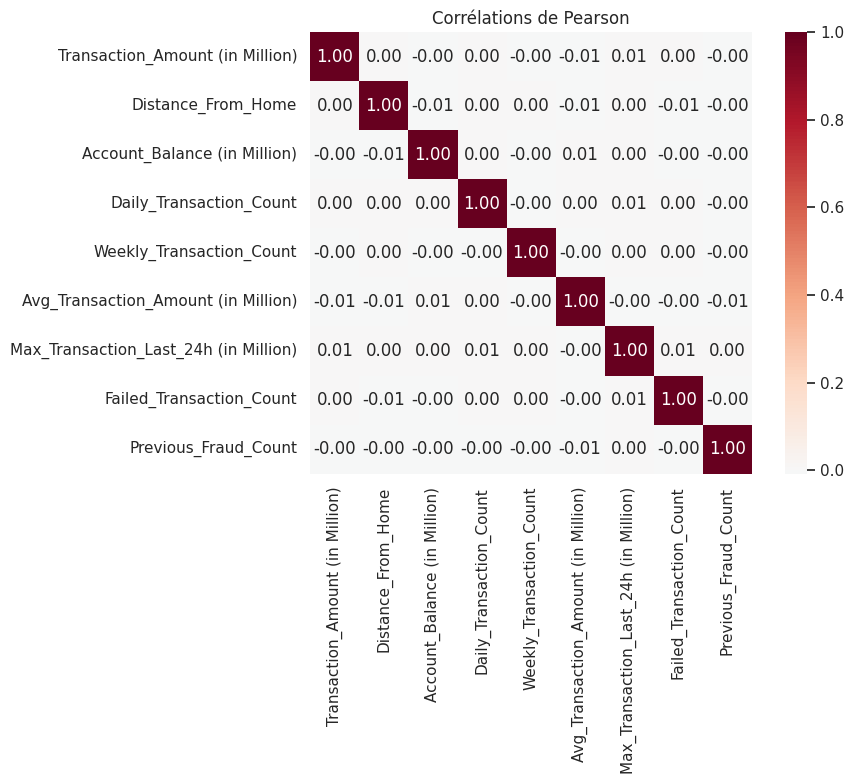

In [106]:
# Corrélations (Pearson) entre variables numériques métier (hors gros identifiants)
num_features = [
    "Transaction_Amount (in Million)",
    "Distance_From_Home",
    "Account_Balance (in Million)",
    "Daily_Transaction_Count",
    "Weekly_Transaction_Count",
    "Avg_Transaction_Amount (in Million)",
    "Max_Transaction_Last_24h (in Million)",
    "Failed_Transaction_Count",
    "Previous_Fraud_Count",
]
corr = df[num_features].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Corrélations de Pearson")
plt.tight_layout()
plt.show()


In [107]:
# Taux de fraude (%) par modalité catégorielle


def taux_fraude_par_colonne(data: pd.DataFrame, col: str, target: str = "Fraud_Label") -> pd.DataFrame:
    d = data.dropna(subset=[col, target]).copy()
    y = d[target].astype(str).str.strip().eq("Fraud").astype(int)
    g = d.assign(_fraud=y).groupby(col, observed=True)["_fraud"].agg(["mean", "count"])
    g = g.rename(columns={"mean": "taux_fraude", "count": "n"})
    g["taux_fraude_%"] = (g["taux_fraude"] * 100).round(2)
    return g.sort_values("taux_fraude", ascending=False)


cat_cols = [
    "Transaction_Type",
    "Merchant_Category",
    "Card_Type",
    "Is_International_Transaction",
    "Is_New_Merchant",
    "Unusual_Time_Transaction",
]
for c in cat_cols:
    print(f"\n--- Taux de fraude par : {c} ---")
    display(taux_fraude_par_colonne(df, c))



--- Taux de fraude par : Transaction_Type ---


,taux_fraude,n,taux_fraude_%
Transaction_Type,,,
Online,0.050383,16712,5.04
ATM,0.047782,16680,4.78
POS,0.047169,16600,4.72



--- Taux de fraude par : Merchant_Category ---


,taux_fraude,n,taux_fraude_%
Merchant_Category,,,
Restaurant,0.050342,8482,5.03
ATM,0.050119,8400,5.01
Fuel,0.048821,8357,4.88
Grocery,0.048110,8252,4.81
Electronics,0.047352,8215,4.74
Clothing,0.045888,8281,4.59



--- Taux de fraude par : Card_Type ---


...

,taux_fraude,n,taux_fraude_%
Is_International_Transaction,,,
Yes,0.061373,25060,6.14
No,0.035497,24932,3.55



--- Taux de fraude par : Is_New_Merchant ---


,taux_fraude,n,taux_fraude_%
Is_New_Merchant,,,
Yes,0.048934,25054,4.89
No,0.048001,24937,4.80



--- Taux de fraude par : Unusual_Time_Transaction ---


,taux_fraude,n,taux_fraude_%
Unusual_Time_Transaction,,,
Yes,0.061367,24883,6.14
No,0.035683,25110,3.57


Points hors moustaches (montant) : 0 (0.00 %)
Plage IQR : [-3.00, 13.00]


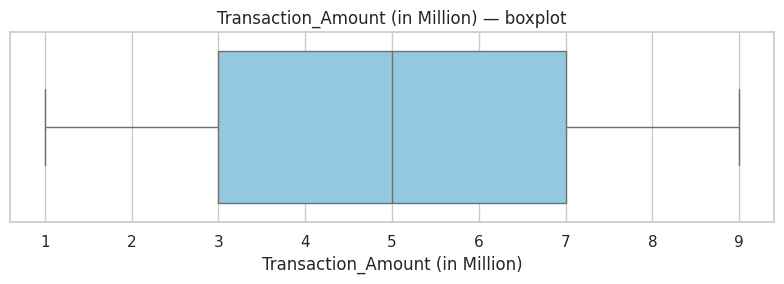

In [108]:
# Outliers sur le montant (règle 1,5 × IQR) + boxplot
amt = df[amt_col].dropna()
q1, q3 = amt.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
out = ((amt < low) | (amt > high))
print(f"Points hors moustaches (montant) : {out.sum():,} ({100 * out.mean():.2f} %)")
print(f"Plage IQR : [{low:.2f}, {high:.2f}]")
fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(x=amt, ax=ax, color="skyblue")
ax.set_title(f"{amt_col} — boxplot")
plt.tight_layout()
plt.show()


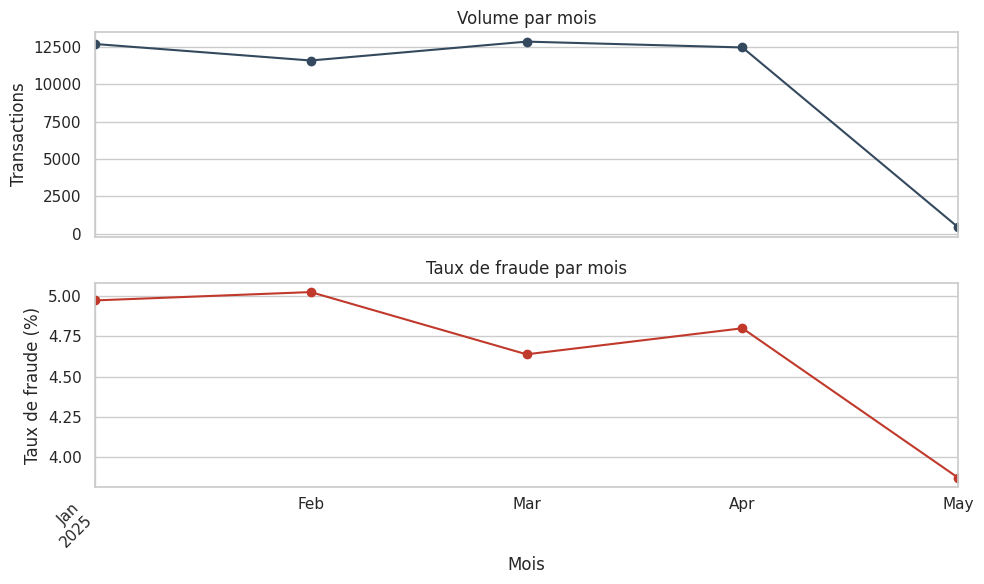

In [109]:
# Tendance temporelle : volume mensuel et taux de fraude
_dt = pd.to_datetime(df["Transaction_Date"], errors="coerce")
tmp = df.assign(
    _month=_dt.dt.to_period("M"),
    _is_fraud=df["Fraud_Label"].astype(str).str.strip().eq("Fraud").astype(int),
)
vol = tmp.groupby("_month", observed=True).size()
rate = tmp.groupby("_month", observed=True)["_is_fraud"].mean() * 100

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
vol.plot(ax=axes[0], marker="o", color="#34495e")
axes[0].set_ylabel("Transactions")
axes[0].set_title("Volume par mois")
rate.plot(ax=axes[1], marker="o", color="#c0392b")
axes[1].set_ylabel("Taux de fraude (%)")
axes[1].set_title("Taux de fraude par mois")
plt.xlabel("Mois")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


,% Normal (ligne),% Fraud (ligne)
Previous_Fraud_Count,,
0.0,95.26,4.74
1.0,95.05,4.95


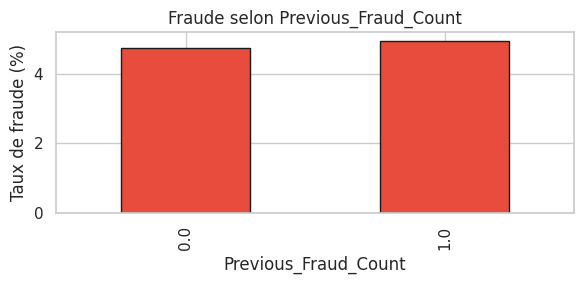

In [110]:
# Lien Previous_Fraud_Count ↔ fraude sur la transaction
d = df.dropna(subset=["Previous_Fraud_Count", "Fraud_Label"]).copy()
d["_f"] = d["Fraud_Label"].astype(str).str.strip().eq("Fraud").astype(int)
ct = pd.crosstab(d["Previous_Fraud_Count"], d["_f"], normalize="index") * 100
ct.columns = ["% Normal (ligne)", "% Fraud (ligne)"]
display(ct.round(2))

fig, ax = plt.subplots(figsize=(6, 3))
d.groupby("Previous_Fraud_Count", observed=True)["_f"].mean().mul(100).plot(
    kind="bar", ax=ax, color="#e74c3c", edgecolor="k"
)
ax.set_xlabel("Previous_Fraud_Count")
ax.set_ylabel("Taux de fraude (%)")
ax.set_title("Fraude selon Previous_Fraud_Count")
plt.tight_layout()
plt.show()


### Synthèse EDA (à interpréter)

- **Déséquilibre** des classes `Normal` / `Fraud` (voir effectifs et ratio).
- **Montants** : comparaison des distributions et des extrêmes (IQR / boxplot).
- **Corrélations** : associations linéaires entre variables numériques (sans causalité).
- **Catégories** : modalités dont le **taux de fraude** se démarque fortement.
- **Temps** : stabilité du volume et du taux mensuel.
- **Previous_Fraud_Count** : comportement conditionnel de la fraude.


## Data cleaning

Objectifs : chaînes normalisées (trim), **cible** binaire exploitable (`1` = fraude, `0` = normal), exclusion des étiquettes invalides, **suppression des doublons**, **imputation** des valeurs manquantes (médiane pour les numériques, mode puis `Inconnu` pour le texte), puis **export** optionnel du jeu prêt pour la modélisation.


In [111]:
# 1) Trim des colonnes texte
for _c in df.select_dtypes(include=["object"]).columns:
    df[_c] = df[_c].apply(lambda x: x.strip() if isinstance(x, str) else x)

# 2) Cible : ne garder que Fraud / Normal (insensible à la casse), puis 1 / 0
df = df.dropna(subset=["Fraud_Label"]).reset_index(drop=True)
_fl = df["Fraud_Label"].astype(str).str.strip().str.casefold()
_n0 = len(df)
df = df.loc[_fl.isin(["fraud", "normal"])].copy()
_fl = df["Fraud_Label"].astype(str).str.strip().str.casefold()
df["Fraud_Label"] = (_fl == "fraud").astype(int)
print(f"Lignes exclues (cible absente ou ≠ Fraud/Normal) : {_n0 - len(df):,}")

# 3) Doublons complets
df = df.drop_duplicates().reset_index(drop=True)
print("Dimensions après nettoyage :", df.shape)
display(df["Fraud_Label"].value_counts())


Lignes exclues (cible absente ou ≠ Fraud/Normal) : 0
Dimensions après nettoyage : (49996, 25)


Fraud_Label
0    47573
1     2423
Name: count, dtype: int64

### Imputation des valeurs manquantes

- **Numérique** : médiane par colonne.  
- **Texte (`object`)** : mode ; si indéterminable, **`Inconnu`**.


In [112]:
df_clean = df.copy()

num_cols_na = [c for c in df_clean.select_dtypes(include=np.number).columns if df_clean[c].isna().any()]
for col in num_cols_na:
    med = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(med)

print("Colonnes numériques imputées (médiane) :", num_cols_na or "aucune")


Colonnes numériques imputées (médiane) : ['Transaction_ID', 'Customer_ID', 'Transaction_Amount (in Million)', 'Merchant_ID', 'Distance_From_Home', 'Device_ID', 'Account_Balance (in Million)', 'Daily_Transaction_Count', 'Weekly_Transaction_Count', 'Avg_Transaction_Amount (in Million)', 'Max_Transaction_Last_24h (in Million)', 'Failed_Transaction_Count', 'Previous_Fraud_Count']


In [113]:
cat_cols_na = [c for c in df_clean.select_dtypes(include="object").columns if df_clean[c].isna().any()]
for col in cat_cols_na:
    m = df_clean[col].mode()
    fill = m.iloc[0] if len(m) else None
    if fill is None:
        df_clean[col] = df_clean[col].fillna("Inconnu")
    else:
        df_clean[col] = df_clean[col].fillna(fill)

for col in df_clean.select_dtypes(include="object").columns:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna("Inconnu")

print("Colonnes texte imputées :", cat_cols_na or "aucune")
reste = df_clean.isna().sum()
reste = reste[reste > 0]
display(reste.to_frame("manquantes") if len(reste) else "Plus aucun NaN.")


Colonnes texte imputées : ['Transaction_Time', 'Transaction_Date', 'Transaction_Type', 'Merchant_Category', 'Transaction_Location', 'Customer_Home_Location', 'IP_Address', 'Card_Type', 'Is_International_Transaction', 'Is_New_Merchant', 'Unusual_Time_Transaction']


'Plus aucun NaN.'

In [114]:
# Jeu final : remplacer `df` pour la suite (modélisation, features, etc.)
df = df_clean.copy()

_out = _repo / "data" / "FraudShield_Banking_Data_clean.csv"
if not _out.parent.is_dir():
    _out = _repo.parent / "data" / "FraudShield_Banking_Data_clean.csv"

df.to_csv(_out, index=False)
print(f"Sauvegardé : {_out.resolve()} — {len(df):,} lignes × {df.shape[1]} colonnes")
df.head()


Sauvegardé : /home/perfect/Documents/GitHub/bank-fraud-detection/data/FraudShield_Banking_Data_clean.csv — 49,996 lignes × 25 colonnes


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,0
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,0
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,0
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,0
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,0


## Feature Engineering

À partir du jeu **nettoyé** (`Fraud_Label` en 0/1), on ajoute des variables dérivées utiles pour la modélisation :

- **Calendrier** : date/heure combinées, jour de la semaine, week-end, mois, trimestre, **heure** et **nuit** (fenêtre type 22h–6h).
- **Encodage cyclique** : `sin` / `cos` pour l’heure et le jour de la semaine (continuité 23h↔0h, dimanche↔lundi).
- **Indicateurs binaires** : `Yes`/`No` → 0/1 pour les colonnes concernées.
- **Ratios risque** : montant par rapport à la moyenne et au max 24h du client ; **log1p** du montant pour les distributions asymétriques.

Le DataFrame `df` est enrichi sur place ; un export optionnel avec suffixe `_features` est proposé en fin de section.


#### Feature engineering — dates & calendrier

À partir de `Transaction_Date` / `Transaction_Time` : horodatage, jour de la semaine, mois, week-end, **nuit** (hors 6h–22h).


In [115]:
# Constantes noms de colonnes (montants)
EPS = 1e-6
amt = "Transaction_Amount (in Million)"
avg_amt = "Avg_Transaction_Amount (in Million)"
max24 = "Max_Transaction_Last_24h (in Million)"

_t = pd.to_datetime(df["Transaction_Time"], format="%H:%M", errors="coerce")
df["order_date_dt"] = pd.to_datetime(df["Transaction_Date"], errors="coerce")
df["hour"] = _t.dt.hour
df["minute"] = _t.dt.minute

if df["hour"].isna().any():
    df["hour"] = df["hour"].fillna(df["hour"].median())
if df["minute"].isna().any():
    df["minute"] = df["minute"].fillna(0)

base = df["order_date_dt"].dt.normalize()
df["transaction_dt"] = base + pd.to_timedelta(df["hour"], unit="h") + pd.to_timedelta(df["minute"], unit="min")

df["day_of_week"] = df["order_date_dt"].dt.dayofweek
df["day_of_month"] = df["order_date_dt"].dt.day
df["month"] = df["order_date_dt"].dt.month
df["quarter"] = df["order_date_dt"].dt.quarter
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

h = df["hour"]
df["is_night"] = ((h < 6) | (h >= 22)).astype(int)


#### Encodage cyclique (sin / cos)

Pour que l’heure et le jour de la semaine soient **continus** (ex. 23h proche de minuit).


In [116]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7.0)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7.0)


#### Indicateurs Yes / No → 0 / 1

Colonnes `Is_International_Transaction`, `Is_New_Merchant`, `Unusual_Time_Transaction`.


In [117]:
def _yes_no_int(x) -> float:
    if pd.isna(x):
        return np.nan
    s = str(x).strip().casefold()
    if s in ("yes", "y", "true", "1"):
        return 1.0
    if s in ("no", "n", "false", "0"):
        return 0.0
    return np.nan


for col in ["Is_International_Transaction", "Is_New_Merchant", "Unusual_Time_Transaction"]:
    df[f"{col}_num"] = df[col].map(_yes_no_int).astype(float)


#### Ratios sur le montant

`log1p` du montant, rapport au montant moyen et au max sur 24h (évite division par zéro avec `EPS`).


In [118]:
df["log_transaction_amount"] = np.log1p(df[amt].clip(lower=0))
df["amount_vs_avg_ratio"] = df[amt] / (df[avg_amt].abs() + EPS)
df["amount_vs_max24_ratio"] = df[amt] / (df[max24].abs() + EPS)

new_cols = [
    "transaction_dt",
    "order_date_dt",
    "hour",
    "minute",
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "is_weekend",
    "is_night",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "Is_International_Transaction_num",
    "Is_New_Merchant_num",
    "Unusual_Time_Transaction_num",
    "log_transaction_amount",
    "amount_vs_avg_ratio",
    "amount_vs_max24_ratio",
]
print(f"{len(new_cols)} nouvelles colonnes créées.")
df[new_cols].head()


20 nouvelles colonnes créées.


,transaction_dt,order_date_dt,hour,minute,day_of_week,day_of_month,month,quarter,is_weekend,is_night,hour_sin,hour_cos,dow_sin,dow_cos,Is_International_Transaction_num,Is_New_Merchant_num,Unusual_Time_Transaction_num,log_transaction_amount,amount_vs_avg_ratio,amount_vs_max24_ratio
0,2025-03-08 10:54:00,2025-03-08,10,54,5,8,3,1,1,0,0.500000,-0.866025,-0.974928,-0.222521,1.0,1.0,0.0,1.945910,2.999999,1.500000
1,2025-01-17 19:23:00,2025-01-17,19,23,4,17,1,1,0,0,-0.965926,0.258819,-0.433884,-0.900969,1.0,1.0,0.0,2.302585,1.800000,1.125000
2,2025-04-30 10:20:00,2025-04-30,10,20,2,30,4,2,0,0,0.500000,-0.866025,0.974928,-0.222521,1.0,0.0,1.0,1.386294,0.600000,0.375000
3,2025-02-21 14:11:00,2025-02-21,14,11,4,21,2,1,0,0,-0.500000,-0.866025,-0.433884,-0.900969,0.0,1.0,1.0,0.693147,0.200000,0.999999
4,2025-04-11 04:12:00,2025-04-11,4,12,4,11,4,2,0,1,0.866025,0.500000,-0.433884,-0.900969,0.0,1.0,0.0,0.693147,0.250000,0.333333


In [119]:
# Aperçu : corrélation de Pearson nouvelles variables numériques vs cible
num_new = df[new_cols].select_dtypes(include=[np.number]).columns.tolist()
_corr = df[num_new + ["Fraud_Label"]].corr(numeric_only=True)["Fraud_Label"].drop("Fraud_Label")
corr_target = _corr.reindex(_corr.abs().sort_values(ascending=False).index)
display(corr_target.to_frame("corr_avec_Fraud_Label").round(4))

print("Dimensions finales :", df.shape)


,corr_avec_Fraud_Label
Is_International_Transaction_num,0.0602
Unusual_Time_Transaction_num,0.0598
dow_cos,0.0089
hour,0.0074
is_night,-0.0057
dow_sin,0.0057
month,-0.0054
hour_cos,-0.0047
minute,-0.0038
is_weekend,-0.0032


Dimensions finales : (49996, 45)


In [120]:
# Export optionnel du jeu enrichi (même dossier `data/` que le CSV brut)
_feat_out = _repo / "data" / "FraudShield_Banking_Data_features.csv"
if not _feat_out.parent.is_dir():
    _feat_out = _repo.parent / "data" / "FraudShield_Banking_Data_features.csv"
df.to_csv(_feat_out, index=False)
print(f"Jeu avec features sauvegardé : {_feat_out.resolve()}")


Jeu avec features sauvegardé : /home/perfect/Documents/GitHub/bank-fraud-detection/data/FraudShield_Banking_Data_features.csv


## Split des données (train / test)

Séparation **stratifiée** sur `Fraud_Label` pour conserver la proportion de fraudes entre l’entraînement et le test. Proportion par défaut : **80 % / 20 %** (`test_size=0.2`, `random_state=42`).

Nécessite **scikit-learn** (`pip install scikit-learn` ou `pip install -e ".[notebooks]"` depuis la racine du dépôt).


In [121]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
RANDOM_STATE = 42

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["Fraud_Label"],
)

print(f"Train : {train_df.shape[0]:,} lignes | Test : {test_df.shape[0]:,} lignes")
print(f"Taux de fraude (train) : {train_df['Fraud_Label'].mean() * 100:.2f} %")
print(f"Taux de fraude (test)  : {test_df['Fraud_Label'].mean() * 100:.2f} %")


Train : 39,996 lignes | Test : 10,000 lignes
Taux de fraude (train) : 4.85 %
Taux de fraude (test)  : 4.85 %


## Choix du modèle (classification binaire)

**Shortlist** — uniquement des algorithmes **très adaptés** à la fraude sur données tabulaires déséquilibrées :

- **Linéaires probabilistes / scalables** : régression logistique, SGD (perte logistique).
- **Ensembles d’arbres** : forêt aléatoire, extra-trees, gradient boosting « classique », **HistGradientBoosting** (souvent le meilleur compromis perf / temps avec scikit-learn).

**Prétraitement** : numériques **standardisés** ; catégories texte en **ordinal** (entiers).  
**Métriques** : ROC-AUC, F1, précision, rappel, exactitude. La colonne `erreur` trace les échecs éventuels.

> Durée d’exécution : typiquement **moins d’une minute** sur ce jeu (plus rapide qu’avec tous les estimateurs sklearn).



#### Modèle — imports scikit-learn

Classificateurs de la shortlist + métriques + pipeline.


In [122]:
import warnings

import joblib
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler


#### Matrices `X` / `y` et colonnes à retirer

On retire la cible, identifiants, IP et champs date/heure bruts (déjà représentés par les features dérivées).


In [123]:
TARGET = "Fraud_Label"
DROP_COLS = [
    TARGET,
    "Transaction_ID",
    "Customer_ID",
    "IP_Address",
    "transaction_dt",
    "order_date_dt",
    "Transaction_Date",
    "Transaction_Time",
]

feat_cols = [c for c in train_df.columns if c not in DROP_COLS]
X_train = train_df[feat_cols]
X_test = test_df[feat_cols]
y_train = train_df[TARGET]
y_test = test_df[TARGET]

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Variables numériques : {len(num_cols)} | catégorielles : {len(cat_cols)}")


Variables numériques : 29 | catégorielles : 8


#### `ColumnTransformer` : StandardScaler + OrdinalEncoder

Les textes sont encodés en entiers ordinaux (adapté aux arbres ; les linéaires servent de baseline).


In [124]:
preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), num_cols),
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                encoded_missing_value=-1,
            ),
            cat_cols,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


#### Fonction d’évaluation (`fit` + métriques)

ROC-AUC via `predict_proba` ou, à défaut, `decision_function`.


In [125]:
def _evaluate(name: str, clf) -> dict:
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    row = {
        "modèle": name,
        "accuracy": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "f1": np.nan,
        "roc_auc": np.nan,
        "erreur": "",
    }
    try:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        est = pipe.named_steps["clf"]
        row["accuracy"] = float(accuracy_score(y_test, y_pred))
        row["precision"] = float(precision_score(y_test, y_pred, zero_division=0))
        row["recall"] = float(recall_score(y_test, y_pred, zero_division=0))
        row["f1"] = float(f1_score(y_test, y_pred, zero_division=0))
        if hasattr(est, "predict_proba"):
            row["roc_auc"] = float(roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1]))
        elif hasattr(est, "decision_function"):
            row["roc_auc"] = float(roc_auc_score(y_test, pipe.decision_function(X_test)))
        else:
            row["roc_auc"] = float("nan")
    except Exception as e:
        row["erreur"] = str(e)[:240]
    return row


#### Shortlist d’estimateurs (mêmes hyperparamètres qu’avant)

In [126]:
RS = RANDOM_STATE

CLASSIFIERS = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000, class_weight="balanced", solver="lbfgs", random_state=RS
    ),
    "SGDClassifier (log_loss)": SGDClassifier(
        loss="log_loss", class_weight="balanced", random_state=RS, max_iter=2000, tol=1e-3
    ),
    "RandomForestClassifier": RandomForestClassifier(
        class_weight="balanced", random_state=RS, n_jobs=-1, n_estimators=100, max_depth=18
    ),
    "ExtraTreesClassifier": ExtraTreesClassifier(
        class_weight="balanced", random_state=RS, n_jobs=-1, n_estimators=100, max_depth=18
    ),
    "GradientBoostingClassifier": GradientBoostingClassifier(
        random_state=RS, max_depth=4, n_estimators=100, learning_rate=0.08
    ),
    "HistGradientBoostingClassifier": HistGradientBoostingClassifier(
        class_weight="balanced", random_state=RS, max_depth=10, max_iter=200
    ),
}


#### Comparaison : entraînement, tableau, meilleur modèle

In [127]:
rows = [_evaluate(n, c) for n, c in CLASSIFIERS.items()]

results_df = (
    pd.DataFrame(rows)
    .sort_values(["roc_auc", "f1"], ascending=False, na_position="last")
    .reset_index(drop=True)
)
display(results_df)

_ok = results_df[results_df["erreur"] == ""].copy()
if len(_ok):
    _ok = _ok.sort_values(["roc_auc", "f1"], ascending=False, na_position="last")
    best = _ok.iloc[0]
    print(
        f"\nMeilleur ROC-AUC (sans erreur d'entraînement) : {best['modèle']} — "
        f"ROC-AUC = {best['roc_auc']:.4f} | F1 = {best['f1']:.4f}"
    )
else:
    print("\nAucun modèle n'a convergé sans erreur ; voir la colonne « erreur ».")


,modèle,accuracy,precision,recall,f1,roc_auc,erreur
0,LogisticRegression,0.6008,0.064348,0.534021,0.114856,0.606333,
1,SGDClassifier (log_loss),0.2949,0.055270,0.841237,0.103724,0.590024,
2,GradientBoostingClassifier,0.9511,0.000000,0.000000,0.000000,0.586347,
3,HistGradientBoostingClassifier,0.5826,0.059049,0.509278,0.105827,0.581336,
4,RandomForestClassifier,0.9515,0.000000,0.000000,0.000000,0.570304,
5,ExtraTreesClassifier,0.9515,0.000000,0.000000,0.000000,0.555035,



Meilleur ROC-AUC (sans erreur d'entraînement) : LogisticRegression — ROC-AUC = 0.6063 | F1 = 0.1149


## Entraînement du modèle final

À partir du **meilleur ROC-AUC** dans `results_df` (lignes sans erreur), on reconstruit un pipeline `prep + clf` avec **`clone`** (préprocesseur neuf), on entraîne sur **`X_train` / `y_train`**, on évalue sur le test, puis on enregistre **`models/fraud_classifier.joblib`**.


In [128]:
# Sélection du meilleur estimateur puis fit complet + sauvegarde
_ok = results_df[results_df["erreur"] == ""].copy()
if _ok.empty:
    raise RuntimeError("Aucun modèle sans erreur : impossible d'entraîner le modèle final.")

best_row = _ok.sort_values(["roc_auc", "f1"], ascending=False, na_position="last").iloc[0]
best_name = best_row["modèle"]
print(f"Modèle retenu : {best_name}")

final_pipeline = Pipeline(
    [
        ("prep", clone(preprocessor)),
        ("clf", clone(CLASSIFIERS[best_name])),
    ]
)
final_pipeline.fit(X_train, y_train)

y_pred_final = final_pipeline.predict(X_test)
if hasattr(final_pipeline.named_steps["clf"], "predict_proba"):
    proba = final_pipeline.predict_proba(X_test)[:, 1]
    print(f"ROC-AUC (test) : {roc_auc_score(y_test, proba):.4f}")
else:
    print("ROC-AUC : N/A (pas de predict_proba)")

print("\nClassification report (test) :")
print(classification_report(y_test, y_pred_final, digits=4))

_models = _repo / "models"
if not _models.is_dir():
    _models = _repo.parent / "models"
_models.mkdir(parents=True, exist_ok=True)
_out_model = _models / "fraud_classifier.joblib"
joblib.dump(final_pipeline, _out_model)
print(f"\nPipeline sauvegardé : {_out_model.resolve()}")


Modèle retenu : LogisticRegression
ROC-AUC (test) : 0.6063

Classification report (test) :
              precision    recall  f1-score   support

           0     0.9622    0.6042    0.7423      9515
           1     0.0643    0.5340    0.1149       485

    accuracy                         0.6008     10000
   macro avg     0.5133    0.5691    0.4286     10000
weighted avg     0.9186    0.6008    0.7119     10000


Pipeline sauvegardé : /home/perfect/Documents/GitHub/bank-fraud-detection/models/fraud_classifier.joblib


## Vérification — rechargement du modèle

Chargement du fichier **`.joblib`** (sans refaire l’entraînement) et prédictions sur un petit échantillon du jeu test.


In [129]:
_check = _repo / "models" / "fraud_classifier.joblib"
if not _check.is_file():
    _check = _repo.parent / "models" / "fraud_classifier.joblib"

pipe_loaded = joblib.load(_check)
print(f"Modèle chargé depuis : {_check.resolve()}")

_sample = X_test.head(8)
if hasattr(pipe_loaded.named_steps["clf"], "predict_proba"):
    p_fraud = pipe_loaded.predict_proba(_sample)[:, 1]
    out = _sample.assign(proba_fraude=p_fraud, predit=pipe_loaded.predict(_sample))
    display(out[["proba_fraude", "predit"]])
else:
    display(pipe_loaded.predict(_sample))


Modèle chargé depuis : /home/perfect/Documents/GitHub/bank-fraud-detection/models/fraud_classifier.joblib


,proba_fraude,predit
1200,0.474500,0
8710,0.661237,1
10347,0.611184,1
31297,0.533257,1
38545,0.374730,0
32825,0.502847,1
5240,0.550442,1
8628,0.467051,0
